In [1]:


from pathlib import Path
from urllib.request import urlretrieve
import json
import re

import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split



CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"

for directory in [RAW_DATA_DIR, PROCESSED_DATA_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("项目根目录：", PROJECT_ROOT.resolve())
print("原始数据目录：", RAW_DATA_DIR.resolve())
print("处理后数据目录：", PROCESSED_DATA_DIR.resolve())

项目根目录： C:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing
原始数据目录： C:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\data\raw
处理后数据目录： C:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\data\processed


In [2]:

TRAIN_RAW_PATH = RAW_DATA_DIR / "banking77_train.csv"
TEST_RAW_PATH = RAW_DATA_DIR / "banking77_test.csv"

print("训练集保存路径：", TRAIN_RAW_PATH)
print("测试集保存路径：", TEST_RAW_PATH)

训练集保存路径： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\data\raw\banking77_train.csv
测试集保存路径： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\data\raw\banking77_test.csv


In [3]:


EXPECTED_COLUMNS = {"text", "category"}


def load_banking77_csv(file_path: Path, source_split: str) -> pd.DataFrame:
    if not file_path.exists():
        raise FileNotFoundError(f"文件不存在：{file_path}")

    try:
        dataframe = pd.read_csv(file_path)
    except Exception as error:
        raise RuntimeError(f"无法读取CSV文件：{file_path}") from error

    if dataframe.empty:
        raise ValueError(f"数据文件为空：{file_path}")

    missing_columns = EXPECTED_COLUMNS - set(dataframe.columns)

    if missing_columns:
        raise ValueError(
            f"{file_path.name}缺少必要列：{sorted(missing_columns)}；"
            f"实际列名：{dataframe.columns.tolist()}"
        )

    dataframe = dataframe[["text", "category"]].copy()
    dataframe["source_split"] = source_split

    return dataframe

In [4]:


original_train_df = load_banking77_csv(
    TRAIN_RAW_PATH,
    source_split="official_train"
)

original_test_df = load_banking77_csv(
    TEST_RAW_PATH,
    source_split="official_test"
)

print("官方训练集形状：", original_train_df.shape)
print("官方测试集形状：", original_test_df.shape)

display(original_train_df.head())

官方训练集形状： (10003, 3)
官方测试集形状： (3080, 3)


,text,category,source_split
0,I am still waiting on my card?,card_arrival,official_train
1,What can I do if my card still hasn't arrived ...,card_arrival,official_train
2,I have been waiting over a week. Is the card s...,card_arrival,official_train
3,Can I track my card while it is in the process...,card_arrival,official_train
4,"How do I know if I will get my card, or if it ...",card_arrival,official_train


In [5]:


print("训练集字段信息：")
original_train_df.info()

print("\n训练集类别数量：")
print(original_train_df["category"].nunique())

print("\n测试集类别数量：")
print(original_test_df["category"].nunique())

print("\n全部类别名称：")
all_categories = sorted(
    set(original_train_df["category"]).union(
        set(original_test_df["category"])
    )
)

for category in all_categories:
    print(category)

训练集字段信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   text          10003 non-null  object
 1   category      10003 non-null  object
 2   source_split  10003 non-null  object
dtypes: object(3)
memory usage: 234.6+ KB

训练集类别数量：
77

测试集类别数量：
77

全部类别名称：
Refund_not_showing_up
activate_my_card
age_limit
apple_pay_or_google_pay
atm_support
automatic_top_up
balance_not_updated_after_bank_transfer
balance_not_updated_after_cheque_or_cash_deposit
beneficiary_not_allowed
cancel_transfer
card_about_to_expire
card_acceptance
card_arrival
card_delivery_estimate
card_linking
card_not_working
card_payment_fee_charged
card_payment_not_recognised
card_payment_wrong_exchange_rate
card_swallowed
cash_withdrawal_charge
cash_withdrawal_not_recognised
change_pin
compromised_card
contactless_not_working
country_support
declined_card_payment
declined_cash_wit

In [6]:

all_data_df = pd.concat(
    [original_train_df, original_test_df],
    axis=0,
    ignore_index=True
)

TARGET_INTENTS = sorted(all_data_df["category"].dropna().unique().tolist())

if len(TARGET_INTENTS) != 77:
    raise ValueError(
        f"预期BANKING77包含77个类别，实际发现{len(TARGET_INTENTS)}个类别。"
    )

print("合并后数据形状：", all_data_df.shape)
print("类别数量：", len(TARGET_INTENTS))
print("总样本数：", len(all_data_df))

合并后数据形状： (13083, 3)
类别数量： 77
总样本数： 13083


In [7]:
print("列名：", all_data_df.columns.tolist())
print("行数：", all_data_df.shape[0])
print("列数：", all_data_df.shape[1])

列名： ['text', 'category', 'source_split']
行数： 13083
列数： 3


处理缺失值

In [8]:
# Cell 9：检查缺失值

missing_value_summary = all_data_df.isna().sum()

print("各字段缺失值数量：")
display(missing_value_summary.to_frame(name="missing_count"))

missing_text_count = int(all_data_df["text"].isna().sum())
missing_category_count = int(all_data_df["category"].isna().sum())

print("文本缺失数量：", missing_text_count)
print("标签缺失数量：", missing_category_count)

各字段缺失值数量：


,missing_count
text,0
category,0
source_split,0


文本缺失数量： 0
标签缺失数量： 0


In [9]:
# Cell 10：检查空文本和空标签

text_as_string = all_data_df["text"].fillna("").astype(str)
category_as_string = all_data_df["category"].fillna("").astype(str)

empty_text_mask = text_as_string.str.strip().eq("")
empty_category_mask = category_as_string.str.strip().eq("")

empty_text_count = int(empty_text_mask.sum())
empty_category_count = int(empty_category_mask.sum())

print("空文本数量：", empty_text_count)
print("空标签数量：", empty_category_count)

if empty_text_count > 0:
    display(all_data_df.loc[empty_text_mask].head(20))

if empty_category_count > 0:
    display(all_data_df.loc[empty_category_mask].head(20))

空文本数量： 0
空标签数量： 0


In [10]:
# Cell 11：删除缺失文本、缺失标签和空字符串

cleaned_data_df = all_data_df.dropna(
    subset=["text", "category"]
).copy()

cleaned_data_df["text"] = cleaned_data_df["text"].astype(str)
cleaned_data_df["category"] = cleaned_data_df["category"].astype(str)

cleaned_data_df = cleaned_data_df[
    cleaned_data_df["text"].str.strip().ne("")
    & cleaned_data_df["category"].str.strip().ne("")
].copy()

cleaned_data_df.reset_index(drop=True, inplace=True)

print("清理前样本数量：", len(all_data_df))
print("清理后样本数量：", len(cleaned_data_df))
print("清理后类别数量：", cleaned_data_df["category"].nunique())

if cleaned_data_df["category"].nunique() != 77:
    raise ValueError("数据清理后类别数量不是77，请检查数据。")

清理前样本数量： 13083
清理后样本数量： 13083
清理后类别数量： 77


标记1

In [11]:
# Cell 12：生成用于重复样本检查的标准化文本
# 这里只用于检查重复，不会覆盖原始text字段

import re


def normalize_text_for_duplicate_check(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


cleaned_data_df["normalized_text"] = cleaned_data_df["text"].apply(
    normalize_text_for_duplicate_check
)

display(
    cleaned_data_df[
        ["text", "normalized_text", "category"]
    ].head()
)

,text,normalized_text,category
0,I am still waiting on my card?,i am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,what can i do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,i have been waiting over a week. is the card s...,card_arrival
3,Can I track my card while it is in the process...,can i track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...","how do i know if i will get my card, or if it ...",card_arrival


In [12]:
# Cell 13：检查完全重复的文本和标签组合

duplicate_mask = cleaned_data_df.duplicated(
    subset=["normalized_text", "category"],
    keep=False
)

duplicate_samples_df = cleaned_data_df[
    duplicate_mask
].copy()

print("重复样本涉及的总行数：", len(duplicate_samples_df))

if not duplicate_samples_df.empty:
    display(
        duplicate_samples_df[
            ["text", "normalized_text", "category"]
        ]
        .sort_values(["normalized_text", "category"])
        .head(50)
    )

重复样本涉及的总行数： 24


,text,normalized_text,category
4576,\nAt which ATMs can I use this card?,at which atms can i use this card?,atm_support
11477,At which ATMs can I use this card?,at which atms can i use this card?,atm_support
6910,Do I need to go to a physical bank to change m...,do i need to go to a physical bank to change m...,change_pin
6965,\nDo I need to go to a physical bank to change...,do i need to go to a physical bank to change m...,change_pin
1722,\nHow do I unblock my PIN?,how do i unblock my pin?,pin_blocked
10557,How do I unblock my PIN?,how do i unblock my pin?,pin_blocked
1246,I can't seem to be able to use my card,i can't seem to be able to use my card,card_not_working
1290,\nI can't seem to be able to use my card\n\n\n,i can't seem to be able to use my card,card_not_working
9921,I don't live in the UK. Can I still get a card?,i don't live in the uk. can i still get a card?,country_support
13073,I don't live in the UK. Can I still get a card?,i don't live in the uk. can i still get a card?,country_support


In [13]:
# Cell 14：检查相同文本是否对应不同标签
# 如果相同文本对应多个标签，可能存在标签冲突

label_count_per_text = (
    cleaned_data_df
    .groupby("normalized_text")["category"]
    .nunique()
)

conflicting_texts = label_count_per_text[
    label_count_per_text > 1
].index

conflict_df = cleaned_data_df[
    cleaned_data_df["normalized_text"].isin(conflicting_texts)
].copy()

print("存在标签冲突的文本数量：", len(conflicting_texts))
print("标签冲突涉及的样本行数：", len(conflict_df))

if not conflict_df.empty:
    display(
        conflict_df[
            ["text", "normalized_text", "category"]
        ]
        .sort_values(["normalized_text", "category"])
        .head(100)
    )

存在标签冲突的文本数量： 0
标签冲突涉及的样本行数： 0


In [14]:
# Cell 15：如果存在标签冲突，先停止处理

if not conflict_df.empty:
    raise ValueError(
        "发现相同文本对应不同标签的情况。"
        "请先检查上方输出，再决定如何处理。"
    )

print("未发现相同文本对应不同标签的问题。")

未发现相同文本对应不同标签的问题。


In [15]:
# Cell 16：在数据划分前删除重复样本
# 防止相同文本进入训练集和测试集造成数据泄漏

deduplicated_data_df = cleaned_data_df.drop_duplicates(
    subset=["normalized_text", "category"],
    keep="first"
).copy()

deduplicated_data_df.reset_index(drop=True, inplace=True)

removed_duplicate_count = (
    len(cleaned_data_df) - len(deduplicated_data_df)
)

print("去重前样本数量：", len(cleaned_data_df))
print("去重后样本数量：", len(deduplicated_data_df))
print("删除的重复样本数量：", removed_duplicate_count)
print("去重后类别数量：", deduplicated_data_df["category"].nunique())

if deduplicated_data_df["category"].nunique() != 77:
    raise ValueError("去重后类别数量不是77，请检查重复样本处理。")

去重前样本数量： 13083
去重后样本数量： 13071
删除的重复样本数量： 12
去重后类别数量： 77


In [16]:
# Cell 17：准备划分数据
# source_split和normalized_text只用于审计，不作为模型输入

data_for_split = deduplicated_data_df[
    ["text", "category", "normalized_text"]
].copy()

print("待划分数据形状：", data_for_split.shape)
display(data_for_split.head())

待划分数据形状： (13071, 3)


,text,category,normalized_text
0,I am still waiting on my card?,card_arrival,i am still waiting on my card?
1,What can I do if my card still hasn't arrived ...,card_arrival,what can i do if my card still hasn't arrived ...
2,I have been waiting over a week. Is the card s...,card_arrival,i have been waiting over a week. is the card s...
3,Can I track my card while it is in the process...,card_arrival,can i track my card while it is in the process...
4,"How do I know if I will get my card, or if it ...",card_arrival,"how do i know if i will get my card, or if it ..."


疑问

In [17]:
# Cell 18：第一次分层划分
# 70%训练集，30%临时数据集

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

train_df, temporary_df = train_test_split(
    data_for_split,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=data_for_split["category"]
)

print("训练集样本数量：", len(train_df))
print("临时数据集样本数量：", len(temporary_df))

训练集样本数量： 9149
临时数据集样本数量： 3922


In [18]:
# Cell 19：第二次分层划分
# 将30%的临时数据平均分成15%验证集和15%测试集

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temporary_df["category"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("训练集样本数量：", len(train_df))
print("验证集样本数量：", len(validation_df))
print("测试集样本数量：", len(test_df))

print(
    "划分后总样本数量：",
    len(train_df) + len(validation_df) + len(test_df)
)

训练集样本数量： 9149
验证集样本数量： 1961
测试集样本数量： 1961
划分后总样本数量： 13071


In [19]:
# Cell 20：检查实际划分比例

total_sample_count = len(data_for_split)

split_summary_df = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "sample_count": [
            len(train_df),
            len(validation_df),
            len(test_df)
        ],
        "actual_ratio": [
            len(train_df) / total_sample_count,
            len(validation_df) / total_sample_count,
            len(test_df) / total_sample_count
        ]
    }
)

display(split_summary_df)

,split,sample_count,actual_ratio
0,train,9149,0.699946
1,validation,1961,0.150027
2,test,1961,0.150027


In [20]:
# Cell 21：检查三个数据集是否都包含全部77类

split_dataframes = {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}

for split_name, dataframe in split_dataframes.items():
    class_count = dataframe["category"].nunique()

    print(f"{split_name}类别数量：{class_count}")

    if class_count != 77:
        raise ValueError(
            f"{split_name}数据集应包含77类，"
            f"实际包含{class_count}类。"
        )

print("训练集、验证集和测试集均包含全部77个类别。")

train类别数量：77
validation类别数量：77
test类别数量：77
训练集、验证集和测试集均包含全部77个类别。


In [21]:
# Cell 22：查看三个数据集的类别分布

def get_class_distribution(
    dataframe: pd.DataFrame,
    split_name: str
) -> pd.DataFrame:

    distribution = (
        dataframe["category"]
        .value_counts()
        .rename_axis("category")
        .reset_index(name="sample_count")
    )

    distribution["sample_ratio"] = (
        distribution["sample_count"] / len(dataframe)
    )

    distribution["split"] = split_name

    return distribution


train_distribution = get_class_distribution(
    train_df,
    "train"
)

validation_distribution = get_class_distribution(
    validation_df,
    "validation"
)

test_distribution = get_class_distribution(
    test_df,
    "test"
)

all_distributions_df = pd.concat(
    [
        train_distribution,
        validation_distribution,
        test_distribution
    ],
    ignore_index=True
)

distribution_table = all_distributions_df.pivot(
    index="category",
    columns="split",
    values="sample_count"
)

display(distribution_table)

split,test,train,validation
category,,,
Refund_not_showing_up,30,141,31
activate_my_card,30,139,30
age_limit,22,105,23
apple_pay_or_google_pay,25,116,25
atm_support,19,87,18
...,...,...,...
virtual_card_not_working,12,57,12
visa_or_mastercard,26,122,27
why_verify_identity,24,113,24


In [22]:
# Cell 23：检查训练集、验证集和测试集之间是否存在文本重叠

train_texts = set(train_df["normalized_text"])
validation_texts = set(validation_df["normalized_text"])
test_texts = set(test_df["normalized_text"])

train_validation_overlap = train_texts.intersection(
    validation_texts
)

train_test_overlap = train_texts.intersection(
    test_texts
)

validation_test_overlap = validation_texts.intersection(
    test_texts
)

print(
    "训练集与验证集重复文本数量：",
    len(train_validation_overlap)
)

print(
    "训练集与测试集重复文本数量：",
    len(train_test_overlap)
)

print(
    "验证集与测试集重复文本数量：",
    len(validation_test_overlap)
)

if (
    train_validation_overlap
    or train_test_overlap
    or validation_test_overlap
):
    raise ValueError(
        "不同数据集之间存在重复文本，可能造成数据泄漏。"
    )

print("三个数据集之间不存在重复文本。")

训练集与验证集重复文本数量： 0
训练集与测试集重复文本数量： 0
验证集与测试集重复文本数量： 0
三个数据集之间不存在重复文本。


In [23]:
# Cell 24：生成最终用于模型训练的数据
# 模型只需要text和category两列

final_train_df = train_df[
    ["text", "category"]
].copy()

final_validation_df = validation_df[
    ["text", "category"]
].copy()

final_test_df = test_df[
    ["text", "category"]
].copy()

print("最终训练集：", final_train_df.shape)
print("最终验证集：", final_validation_df.shape)
print("最终测试集：", final_test_df.shape)

display(final_train_df.head())

最终训练集： (9149, 2)
最终验证集： (1961, 2)
最终测试集： (1961, 2)


,text,category
0,I want to get Visa and Mastercard,visa_or_mastercard
1,Why is identity verification required?,why_verify_identity
2,I tried using my ATM card at your Notting Hill...,declined_cash_withdrawal
3,What do I do with my card PIN?,get_physical_card
4,I can't find the top-up verification code.,verify_top_up


In [24]:
# Cell 25：创建处理后数据目录

from pathlib import Path

if "PROCESSED_DATA_DIR" not in globals():
    CURRENT_DIR = Path.cwd()

    if CURRENT_DIR.name == "notebooks":
        PROJECT_ROOT = CURRENT_DIR.parent
    else:
        PROJECT_ROOT = CURRENT_DIR

    PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("处理后数据目录：", PROCESSED_DATA_DIR.resolve())

处理后数据目录： C:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\data\processed


In [25]:
# Cell 26：保存训练集、验证集和测试集

TRAIN_SAVE_PATH = PROCESSED_DATA_DIR / "train_77.csv"
VALIDATION_SAVE_PATH = PROCESSED_DATA_DIR / "validation_77.csv"
TEST_SAVE_PATH = PROCESSED_DATA_DIR / "test_77.csv"

final_train_df.to_csv(
    TRAIN_SAVE_PATH,
    index=False,
    encoding="utf-8-sig"
)

final_validation_df.to_csv(
    VALIDATION_SAVE_PATH,
    index=False,
    encoding="utf-8-sig"
)

final_test_df.to_csv(
    TEST_SAVE_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("训练集保存路径：", TRAIN_SAVE_PATH)
print("验证集保存路径：", VALIDATION_SAVE_PATH)
print("测试集保存路径：", TEST_SAVE_PATH)

训练集保存路径： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\data\processed\train_77.csv
验证集保存路径： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\data\processed\validation_77.csv
测试集保存路径： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\data\processed\test_77.csv


In [26]:
# Cell 27：重新读取保存后的文件，确认文件可以正常使用

saved_train_df = pd.read_csv(TRAIN_SAVE_PATH)
saved_validation_df = pd.read_csv(VALIDATION_SAVE_PATH)
saved_test_df = pd.read_csv(TEST_SAVE_PATH)

print("训练集形状：", saved_train_df.shape)
print("验证集形状：", saved_validation_df.shape)
print("测试集形状：", saved_test_df.shape)

display(saved_train_df.head())

训练集形状： (9149, 2)
验证集形状： (1961, 2)
测试集形状： (1961, 2)


,text,category
0,I want to get Visa and Mastercard,visa_or_mastercard
1,Why is identity verification required?,why_verify_identity
2,I tried using my ATM card at your Notting Hill...,declined_cash_withdrawal
3,What do I do with my card PIN?,get_physical_card
4,I can't find the top-up verification code.,verify_top_up


In [27]:
# Cell 28：检查保存后的字段、空数据和类别数量

expected_columns = ["text", "category"]

saved_datasets = {
    "train": saved_train_df,
    "validation": saved_validation_df,
    "test": saved_test_df,
}

for split_name, dataframe in saved_datasets.items():

    if dataframe.empty:
        raise ValueError(f"{split_name}数据集为空。")

    if dataframe.columns.tolist() != expected_columns:
        raise ValueError(
            f"{split_name}字段错误。"
            f"预期字段：{expected_columns}，"
            f"实际字段：{dataframe.columns.tolist()}"
        )

    if dataframe["text"].isna().any():
        raise ValueError(f"{split_name}中存在缺失文本。")

    if dataframe["category"].isna().any():
        raise ValueError(f"{split_name}中存在缺失标签。")

    class_count = dataframe["category"].nunique()

    if class_count != 77:
        raise ValueError(
            f"{split_name}类别数量错误，"
            f"预期77类，实际{class_count}类。"
        )

    print(
        f"{split_name}检查通过："
        f"{len(dataframe)}条样本，{class_count}个类别"
    )

train检查通过：9149条样本，77个类别
validation检查通过：1961条样本，77个类别
test检查通过：1961条样本，77个类别


In [28]:
# Cell 29：检查三个数据集的样本总数和实际比例

total_saved_samples = (
    len(saved_train_df)
    + len(saved_validation_df)
    + len(saved_test_df)
)

split_ratio_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "sample_count": [
            len(saved_train_df),
            len(saved_validation_df),
            len(saved_test_df),
        ],
        "sample_ratio": [
            len(saved_train_df) / total_saved_samples,
            len(saved_validation_df) / total_saved_samples,
            len(saved_test_df) / total_saved_samples,
        ],
    }
)

print("保存后的总样本数量：", total_saved_samples)

display(split_ratio_summary)

保存后的总样本数量： 13071


,split,sample_count,sample_ratio
0,train,9149,0.699946
1,validation,1961,0.150027
2,test,1961,0.150027


In [29]:
# Cell 30：再次检查三个数据集之间是否存在重复文本

import re


def normalize_text_for_check(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


train_text_set = set(
    saved_train_df["text"].apply(normalize_text_for_check)
)

validation_text_set = set(
    saved_validation_df["text"].apply(normalize_text_for_check)
)

test_text_set = set(
    saved_test_df["text"].apply(normalize_text_for_check)
)

train_validation_overlap = train_text_set.intersection(
    validation_text_set
)

train_test_overlap = train_text_set.intersection(
    test_text_set
)

validation_test_overlap = validation_text_set.intersection(
    test_text_set
)

print(
    "训练集与验证集重复文本数量：",
    len(train_validation_overlap)
)

print(
    "训练集与测试集重复文本数量：",
    len(train_test_overlap)
)

print(
    "验证集与测试集重复文本数量：",
    len(validation_test_overlap)
)

if (
    train_validation_overlap
    or train_test_overlap
    or validation_test_overlap
):
    raise ValueError(
        "不同数据集之间存在重复文本，可能发生数据泄漏。"
    )

print("数据集之间不存在重复文本。")

训练集与验证集重复文本数量： 0
训练集与测试集重复文本数量： 0
验证集与测试集重复文本数量： 0
数据集之间不存在重复文本。


In [30]:
# Cell 31：查看三个数据集的类别分布

def calculate_class_distribution(
    dataframe: pd.DataFrame,
    split_name: str
) -> pd.DataFrame:

    distribution = (
        dataframe["category"]
        .value_counts()
        .rename_axis("category")
        .reset_index(name="sample_count")
    )

    distribution["sample_ratio"] = (
        distribution["sample_count"] / len(dataframe)
    )

    distribution["split"] = split_name

    return distribution


train_distribution = calculate_class_distribution(
    saved_train_df,
    "train"
)

validation_distribution = calculate_class_distribution(
    saved_validation_df,
    "validation"
)

test_distribution = calculate_class_distribution(
    saved_test_df,
    "test"
)

all_distribution_df = pd.concat(
    [
        train_distribution,
        validation_distribution,
        test_distribution,
    ],
    ignore_index=True
)

class_count_table = all_distribution_df.pivot(
    index="category",
    columns="split",
    values="sample_count"
)

display(class_count_table)

split,test,train,validation
category,,,
Refund_not_showing_up,30,141,31
activate_my_card,30,139,30
age_limit,22,105,23
apple_pay_or_google_pay,25,116,25
atm_support,19,87,18
...,...,...,...
virtual_card_not_working,12,57,12
visa_or_mastercard,26,122,27
why_verify_identity,24,113,24


In [31]:
# Cell 32：保存类别分布报告

REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_DISTRIBUTION_SAVE_PATH = (
    REPORT_DIR / "class_distribution_77.csv"
)

all_distribution_df.to_csv(
    CLASS_DISTRIBUTION_SAVE_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "类别分布报告保存路径：",
    CLASS_DISTRIBUTION_SAVE_PATH
)

类别分布报告保存路径： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\reports\class_distribution_77.csv


In [32]:
# Cell 33：建立类别名称与数字编号之间的映射
# 后续模型通常需要将字符串标签转换为数字标签

import json


all_labels = sorted(
    saved_train_df["category"].unique().tolist()
)

if len(all_labels) != 77:
    raise ValueError(
        f"标签数量错误，预期77，实际{len(all_labels)}。"
    )

label_to_id = {
    label: index
    for index, label in enumerate(all_labels)
}

id_to_label = {
    index: label
    for label, index in label_to_id.items()
}

print("类别数量：", len(label_to_id))

for label, label_id in list(label_to_id.items())[:10]:
    print(f"{label_id}: {label}")

类别数量： 77
0: Refund_not_showing_up
1: activate_my_card
2: age_limit
3: apple_pay_or_google_pay
4: atm_support
5: automatic_top_up
6: balance_not_updated_after_bank_transfer
7: balance_not_updated_after_cheque_or_cash_deposit
8: beneficiary_not_allowed
9: cancel_transfer


In [33]:
# Cell 34：保存类别编号映射

LABEL_TO_ID_PATH = (
    PROCESSED_DATA_DIR / "label_to_id.json"
)

ID_TO_LABEL_PATH = (
    PROCESSED_DATA_DIR / "id_to_label.json"
)

with open(
    LABEL_TO_ID_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        label_to_id,
        file,
        ensure_ascii=False,
        indent=4
    )

with open(
    ID_TO_LABEL_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        id_to_label,
        file,
        ensure_ascii=False,
        indent=4
    )

print("label_to_id保存路径：", LABEL_TO_ID_PATH)
print("id_to_label保存路径：", ID_TO_LABEL_PATH)

label_to_id保存路径： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\data\processed\label_to_id.json
id_to_label保存路径： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\data\processed\id_to_label.json


In [34]:
# Cell 35：阶段0最终状态汇总

stage_zero_summary = pd.DataFrame(
    {
        "item": [
            "训练集样本数",
            "验证集样本数",
            "测试集样本数",
            "总样本数",
            "类别数量",
            "训练-验证重复文本",
            "训练-测试重复文本",
            "验证-测试重复文本",
        ],
        "value": [
            len(saved_train_df),
            len(saved_validation_df),
            len(saved_test_df),
            total_saved_samples,
            saved_train_df["category"].nunique(),
            len(train_validation_overlap),
            len(train_test_overlap),
            len(validation_test_overlap),
        ],
    }
)

display(stage_zero_summary)

print("阶段0完成：")
print("1. BANKING77全部77类数据已加载")
print("2. 缺失值、空文本和重复文本已处理")
print("3. 数据已按70%/15%/15%分层划分")
print("4. 数据集之间未发现重复文本")
print("5. 训练集、验证集和测试集已保存")
print("6. 类别名称与数字编号映射已保存")
print("7. 当前尚未进行模型训练")

,item,value
0,训练集样本数,9149
1,验证集样本数,1961
2,测试集样本数,1961
3,总样本数,13071
4,类别数量,77
5,训练-验证重复文本,0
6,训练-测试重复文本,0
7,验证-测试重复文本,0


阶段0完成：
1. BANKING77全部77类数据已加载
2. 缺失值、空文本和重复文本已处理
3. 数据已按70%/15%/15%分层划分
4. 数据集之间未发现重复文本
5. 训练集、验证集和测试集已保存
6. 类别名称与数字编号映射已保存
7. 当前尚未进行模型训练


### Stage 2

In [35]:
# Cell 36：导入传统机器学习阶段需要的库

import time
import sklearn
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

print("scikit-learn版本：", sklearn.__version__)

scikit-learn版本： 1.6.1


In [36]:
# Cell 37：读取已经保存的训练集、验证集和测试集

train_df = pd.read_csv(TRAIN_SAVE_PATH)
validation_df = pd.read_csv(VALIDATION_SAVE_PATH)
test_df = pd.read_csv(TEST_SAVE_PATH)

print("训练集形状：", train_df.shape)
print("验证集形状：", validation_df.shape)
print("测试集形状：", test_df.shape)

display(train_df.head())

训练集形状： (9149, 2)
验证集形状： (1961, 2)
测试集形状： (1961, 2)


,text,category
0,I want to get Visa and Mastercard,visa_or_mastercard
1,Why is identity verification required?,why_verify_identity
2,I tried using my ATM card at your Notting Hill...,declined_cash_withdrawal
3,What do I do with my card PIN?,get_physical_card
4,I can't find the top-up verification code.,verify_top_up


In [37]:
# Cell 38：再次检查数据结构

required_columns = ["text", "category"]

datasets = {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}

for split_name, dataframe in datasets.items():

    if dataframe.empty:
        raise ValueError(f"{split_name}数据集为空。")

    if dataframe.columns.tolist() != required_columns:
        raise ValueError(
            f"{split_name}字段错误。"
            f"预期：{required_columns}，"
            f"实际：{dataframe.columns.tolist()}"
        )

    if dataframe[required_columns].isna().any().any():
        raise ValueError(f"{split_name}中存在缺失值。")

    if dataframe["category"].nunique() != 77:
        raise ValueError(
            f"{split_name}类别数量不是77，"
            f"实际为{dataframe['category'].nunique()}。"
        )

    print(
        f"{split_name}检查通过："
        f"{len(dataframe)}条样本，"
        f"{dataframe['category'].nunique()}个类别"
    )

train检查通过：9149条样本，77个类别
validation检查通过：1961条样本，77个类别
test检查通过：1961条样本，77个类别


In [38]:
# Cell 39：划分输入特征X和标签y

X_train = train_df["text"]
y_train = train_df["category"]

X_validation = validation_df["text"]
y_validation = validation_df["category"]

X_test = test_df["text"]
y_test = test_df["category"]

print("X_train样本数：", len(X_train))
print("y_train样本数：", len(y_train))

print("X_validation样本数：", len(X_validation))
print("y_validation样本数：", len(y_validation))

print("X_test样本数：", len(X_test))
print("y_test样本数：", len(y_test))

X_train样本数： 9149
y_train样本数： 9149
X_validation样本数： 1961
y_validation样本数： 1961
X_test样本数： 1961
y_test样本数： 1961


In [39]:
# Cell 40：创建TF-IDF特征提取器

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer="word",
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

print(tfidf_vectorizer)

TfidfVectorizer(max_df=0.95, min_df=2, sublinear_tf=True)


In [40]:
# Cell 41：在训练集上学习TF-IDF词表和IDF权重

tfidf_start_time = time.perf_counter()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

tfidf_fit_time = time.perf_counter() - tfidf_start_time

print("训练集TF-IDF矩阵形状：", X_train_tfidf.shape)
print("词表大小：", len(tfidf_vectorizer.vocabulary_))
print(f"TF-IDF拟合耗时：{tfidf_fit_time:.4f}秒")

训练集TF-IDF矩阵形状： (9149, 1416)
词表大小： 1416
TF-IDF拟合耗时：0.0387秒


In [41]:
# Cell 42：使用训练集学到的规则转换验证集和测试集

X_validation_tfidf = tfidf_vectorizer.transform(
    X_validation
)

X_test_tfidf = tfidf_vectorizer.transform(
    X_test
)

print("训练集TF-IDF形状：", X_train_tfidf.shape)
print("验证集TF-IDF形状：", X_validation_tfidf.shape)
print("测试集TF-IDF形状：", X_test_tfidf.shape)

assert X_train_tfidf.shape[1] == X_validation_tfidf.shape[1]
assert X_train_tfidf.shape[1] == X_test_tfidf.shape[1]

print("三个数据集的特征维度一致。")

训练集TF-IDF形状： (9149, 1416)
验证集TF-IDF形状： (1961, 1416)
测试集TF-IDF形状： (1961, 1416)
三个数据集的特征维度一致。


In [42]:
# Cell 43：查看TF-IDF特征名称

feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF特征总数：", len(feature_names))
print("前50个特征：")
print(feature_names[:50])

TF-IDF特征总数： 1416
前50个特征：
['00' '000' '10' '100' '18' '1l' '20' '200' '2018' '30' '3d' '40' '500'
 '5x' '80' 'able' 'about' 'abroad' 'absolutely' 'accept' 'acceptable'
 'accepted' 'accepting' 'accepts' 'access' 'accessed' 'accessing'
 'accident' 'accidentally' 'accidently' 'according' 'account' 'accounts'
 'accurate' 'acquiring' 'across' 'activate' 'activated' 'activating'
 'activation' 'active' 'activity' 'actual' 'actually' 'add' 'added'
 'adding' 'additional' 'address' 'adress']


In [43]:
# Cell 44：查看一条工单转换后的非零TF-IDF特征

sample_index = 0

sample_text = X_train.iloc[sample_index]
sample_vector = X_train_tfidf[sample_index]

nonzero_feature_indices = sample_vector.nonzero()[1]
nonzero_feature_values = sample_vector.data

sample_features_df = pd.DataFrame(
    {
        "feature": feature_names[nonzero_feature_indices],
        "tfidf_value": nonzero_feature_values,
    }
).sort_values(
    by="tfidf_value",
    ascending=False
)

print("原始文本：")
print(sample_text)

print("\n该文本的TF-IDF特征：")
display(sample_features_df)

原始文本：
I want to get Visa and Mastercard

该文本的TF-IDF特征：


,feature,tfidf_value
3,visa,0.532782
5,mastercard,0.525864
0,want,0.436628
2,get,0.336363
4,and,0.307803
1,to,0.202688


In [44]:
# Cell 45：创建逻辑回归Baseline

logistic_regression_baseline = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
)

print(logistic_regression_baseline)

LogisticRegression(max_iter=1000, random_state=42)


In [45]:
# Cell 46：训练逻辑回归Baseline

training_start_time = time.perf_counter()

logistic_regression_baseline.fit(
    X_train_tfidf,
    y_train
)

training_time = time.perf_counter() - training_start_time

print("逻辑回归训练完成。")
print(f"训练耗时：{training_time:.4f}秒")
print("模型类别数量：", len(logistic_regression_baseline.classes_))

逻辑回归训练完成。
训练耗时：0.9145秒
模型类别数量： 77


In [46]:
# Cell 47：在验证集上进行预测

validation_prediction_start_time = time.perf_counter()

validation_predictions = logistic_regression_baseline.predict(
    X_validation_tfidf
)

validation_prediction_time = (
    time.perf_counter() - validation_prediction_start_time
)

print("验证集预测完成。")
print("预测结果数量：", len(validation_predictions))
print(f"验证集总推理耗时：{validation_prediction_time:.4f}秒")

print(
    "平均每条工单推理耗时：",
    f"{validation_prediction_time / len(validation_df):.8f}秒"
)

验证集预测完成。
预测结果数量： 1961
验证集总推理耗时：0.0020秒
平均每条工单推理耗时： 0.00000101秒


In [47]:
# Cell 48：计算验证集总体指标

validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

validation_macro_precision = precision_score(
    y_validation,
    validation_predictions,
    average="macro",
    zero_division=0
)

validation_macro_recall = recall_score(
    y_validation,
    validation_predictions,
    average="macro",
    zero_division=0
)

validation_macro_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="macro",
    zero_division=0
)

baseline_metrics_df = pd.DataFrame(
    {
        "model": ["TF-IDF + Logistic Regression"],
        "accuracy": [validation_accuracy],
        "macro_precision": [validation_macro_precision],
        "macro_recall": [validation_macro_recall],
        "macro_f1": [validation_macro_f1],
        "training_time_seconds": [training_time],
        "validation_inference_time_seconds": [
            validation_prediction_time
        ],
    }
)

display(baseline_metrics_df)

,model,accuracy,macro_precision,macro_recall,macro_f1,training_time_seconds,validation_inference_time_seconds
0,TF-IDF + Logistic Regression,0.873534,0.877014,0.870031,0.870212,0.91454,0.001977


In [48]:
# Cell 49：生成77个类别的详细分类报告

validation_classification_report = classification_report(
    y_validation,
    validation_predictions,
    labels=logistic_regression_baseline.classes_,
    output_dict=True,
    zero_division=0,
)

validation_report_df = (
    pd.DataFrame(validation_classification_report)
    .transpose()
)

display(validation_report_df)

,precision,recall,f1-score,support
Refund_not_showing_up,0.966667,0.935484,0.950820,31.000000
activate_my_card,1.000000,0.900000,0.947368,30.000000
age_limit,0.958333,1.000000,0.978723,23.000000
apple_pay_or_google_pay,1.000000,0.960000,0.979592,25.000000
atm_support,0.888889,0.888889,0.888889,18.000000
...,...,...,...,...
wrong_amount_of_cash_received,0.848485,0.848485,0.848485,33.000000
wrong_exchange_rate_for_cash_withdrawal,0.925926,0.833333,0.877193,30.000000
accuracy,0.873534,0.873534,0.873534,0.873534
macro avg,0.877014,0.870031,0.870212,1961.000000


In [49]:
# Cell 50：查看验证集中Recall最低的10个类别

per_class_report_df = validation_report_df.loc[
    logistic_regression_baseline.classes_
].copy()

lowest_recall_classes = (
    per_class_report_df
    .sort_values(by="recall", ascending=True)
    .head(10)
)

print("Recall最低的10个类别：")
display(
    lowest_recall_classes[
        ["precision", "recall", "f1-score", "support"]
    ]
)

Recall最低的10个类别：


,precision,recall,f1-score,support
virtual_card_not_working,0.714286,0.416667,0.526316,12.0
lost_or_stolen_card,0.923077,0.631579,0.750000,19.0
card_delivery_estimate,0.714286,0.652174,0.681818,23.0
card_not_working,0.750000,0.681818,0.714286,22.0
declined_transfer,0.750000,0.692308,0.720000,26.0
transfer_fee_charged,0.821429,0.718750,0.766667,32.0
compromised_card,0.700000,0.736842,0.717949,19.0
pin_blocked,0.944444,0.739130,0.829268,23.0
automatic_top_up,1.000000,0.760000,0.863636,25.0
unable_to_verify_identity,0.800000,0.761905,0.780488,21.0


In [50]:
# Cell 51：计算验证集混淆矩阵

class_labels = logistic_regression_baseline.classes_

validation_confusion_matrix = confusion_matrix(
    y_validation,
    validation_predictions,
    labels=class_labels,
)

print(
    "混淆矩阵形状：",
    validation_confusion_matrix.shape
)

assert validation_confusion_matrix.shape == (77, 77)

print("77分类混淆矩阵计算完成。")

混淆矩阵形状： (77, 77)
77分类混淆矩阵计算完成。


In [51]:
# Cell 52：找出验证集中最常见的类别混淆组合

confusion_records = []

for true_index, true_label in enumerate(class_labels):
    for predicted_index, predicted_label in enumerate(class_labels):

        if true_index == predicted_index:
            continue

        confusion_count = validation_confusion_matrix[
            true_index,
            predicted_index
        ]

        if confusion_count > 0:
            confusion_records.append(
                {
                    "true_category": true_label,
                    "predicted_category": predicted_label,
                    "confusion_count": int(confusion_count),
                }
            )

confusion_pairs_df = pd.DataFrame(confusion_records)

top_confusion_pairs_df = (
    confusion_pairs_df
    .sort_values(
        by="confusion_count",
        ascending=False
    )
    .head(20)
)

print("验证集中最常见的20组错误混淆：")
display(top_confusion_pairs_df)

验证集中最常见的20组错误混淆：


,true_category,predicted_category,confusion_count
185,virtual_card_not_working,get_disposable_virtual_card,5
192,wrong_amount_of_cash_received,declined_cash_withdrawal,4
166,transfer_fee_charged,top_up_by_bank_transfer_charge,4
170,transfer_not_received_by_recipient,balance_not_updated_after_bank_transfer,3
178,unable_to_verify_identity,why_verify_identity,3
176,transfer_timing,pending_transfer,3
27,card_delivery_estimate,order_physical_card,3
136,pin_blocked,get_physical_card,3
177,unable_to_verify_identity,verify_my_identity,2
29,card_linking,order_physical_card,2


In [52]:
# Cell 53：保存Baseline验证结果

BASELINE_REPORT_DIR = REPORT_DIR / "ml_baseline"
BASELINE_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BASELINE_METRICS_PATH = (
    BASELINE_REPORT_DIR
    / "logistic_regression_validation_metrics.csv"
)

CLASSIFICATION_REPORT_PATH = (
    BASELINE_REPORT_DIR
    / "logistic_regression_classification_report.csv"
)

CONFUSION_PAIRS_PATH = (
    BASELINE_REPORT_DIR
    / "logistic_regression_top_confusions.csv"
)

baseline_metrics_df.to_csv(
    BASELINE_METRICS_PATH,
    index=False,
    encoding="utf-8-sig"
)

validation_report_df.to_csv(
    CLASSIFICATION_REPORT_PATH,
    encoding="utf-8-sig"
)

top_confusion_pairs_df.to_csv(
    CONFUSION_PAIRS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("总体指标：", BASELINE_METRICS_PATH)
print("分类报告：", CLASSIFICATION_REPORT_PATH)
print("主要混淆类别：", CONFUSION_PAIRS_PATH)

总体指标： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\reports\ml_baseline\logistic_regression_validation_metrics.csv
分类报告： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\reports\ml_baseline\logistic_regression_classification_report.csv
主要混淆类别： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\reports\ml_baseline\logistic_regression_top_confusions.csv


In [53]:
# Cell 54：阶段状态总结

print("当前阶段完成：")
print("1. 使用训练集拟合了TF-IDF")
print("2. 验证集和测试集只进行了transform")
print("3. 建立了TF-IDF + 逻辑回归Baseline")
print("4. 只在验证集上进行了模型评价")
print("5. 计算了Accuracy和Macro指标")
print("6. 找出了Recall最低的类别")
print("7. 找出了最常见的类别混淆")
print("8. 尚未使用测试集评价模型")

当前阶段完成：
1. 使用训练集拟合了TF-IDF
2. 验证集和测试集只进行了transform
3. 建立了TF-IDF + 逻辑回归Baseline
4. 只在验证集上进行了模型评价
5. 计算了Accuracy和Macro指标
6. 找出了Recall最低的类别
7. 找出了最常见的类别混淆
8. 尚未使用测试集评价模型


## Baseline+ naive bayes

In [54]:
# Cell 68：导入多项式朴素贝叶斯

from sklearn.naive_bayes import MultinomialNB

print("MultinomialNB导入完成。")

MultinomialNB导入完成。


In [55]:
# Cell 69：确认前面的TF-IDF数据已经存在

required_variables = [
    "X_train_tfidf",
    "X_validation_tfidf",
    "y_train",
    "y_validation",
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise NameError(
            f"缺少变量：{variable_name}，"
            "请先完成TF-IDF特征提取。"
        )

print("训练集TF-IDF形状：", X_train_tfidf.shape)
print("验证集TF-IDF形状：", X_validation_tfidf.shape)

print("TF-IDF数据检查通过。")

训练集TF-IDF形状： (9149, 1416)
验证集TF-IDF形状： (1961, 1416)
TF-IDF数据检查通过。


In [56]:
# Cell 70：创建多项式朴素贝叶斯模型

naive_bayes_model = MultinomialNB(
    alpha=1.0
)

print(naive_bayes_model)

MultinomialNB()


In [57]:
# Cell 71：训练朴素贝叶斯模型

import time

nb_training_start_time = time.perf_counter()

naive_bayes_model.fit(
    X_train_tfidf,
    y_train
)

nb_training_time = (
    time.perf_counter()
    - nb_training_start_time
)

print("朴素贝叶斯训练完成。")
print(f"训练耗时：{nb_training_time:.6f}秒")
print("模型类别数量：", len(naive_bayes_model.classes_))

朴素贝叶斯训练完成。
训练耗时：0.022907秒
模型类别数量： 77


In [58]:
# Cell 72：在验证集上预测

nb_prediction_start_time = time.perf_counter()

nb_validation_predictions = naive_bayes_model.predict(
    X_validation_tfidf
)

nb_prediction_time = (
    time.perf_counter()
    - nb_prediction_start_time
)

print("验证集预测完成。")
print("预测样本数量：", len(nb_validation_predictions))

print(
    f"验证集总推理耗时："
    f"{nb_prediction_time:.6f}秒"
)

print(
    "平均每条工单推理耗时：",
    f"{nb_prediction_time / len(y_validation):.8f}秒"
)

验证集预测完成。
预测样本数量： 1961
验证集总推理耗时：0.001711秒
平均每条工单推理耗时： 0.00000087秒


In [59]:
# Cell 73：计算朴素贝叶斯验证集指标

nb_validation_accuracy = accuracy_score(
    y_validation,
    nb_validation_predictions
)

nb_validation_macro_precision = precision_score(
    y_validation,
    nb_validation_predictions,
    average="macro",
    zero_division=0
)

nb_validation_macro_recall = recall_score(
    y_validation,
    nb_validation_predictions,
    average="macro",
    zero_division=0
)

nb_validation_macro_f1 = f1_score(
    y_validation,
    nb_validation_predictions,
    average="macro",
    zero_division=0
)

nb_metrics_df = pd.DataFrame(
    {
        "model": [
            "TF-IDF + Multinomial Naive Bayes"
        ],
        "accuracy": [
            nb_validation_accuracy
        ],
        "macro_precision": [
            nb_validation_macro_precision
        ],
        "macro_recall": [
            nb_validation_macro_recall
        ],
        "macro_f1": [
            nb_validation_macro_f1
        ],
        "training_time_seconds": [
            nb_training_time
        ],
        "validation_inference_time_seconds": [
            nb_prediction_time
        ],
    }
)

display(nb_metrics_df)

,model,accuracy,macro_precision,macro_recall,macro_f1,training_time_seconds,validation_inference_time_seconds
0,TF-IDF + Multinomial Naive Bayes,0.836818,0.859977,0.817761,0.822571,0.022907,0.001711


In [60]:
# Cell 74：生成朴素贝叶斯77类详细报告

nb_classification_report = classification_report(
    y_validation,
    nb_validation_predictions,
    labels=naive_bayes_model.classes_,
    output_dict=True,
    zero_division=0,
)

nb_report_df = (
    pd.DataFrame(nb_classification_report)
    .transpose()
)

display(nb_report_df)

,precision,recall,f1-score,support
Refund_not_showing_up,0.965517,0.903226,0.933333,31.000000
activate_my_card,0.725000,0.966667,0.828571,30.000000
age_limit,1.000000,1.000000,1.000000,23.000000
apple_pay_or_google_pay,0.960000,0.960000,0.960000,25.000000
atm_support,0.846154,0.611111,0.709677,18.000000
...,...,...,...,...
wrong_amount_of_cash_received,0.789474,0.909091,0.845070,33.000000
wrong_exchange_rate_for_cash_withdrawal,0.870968,0.900000,0.885246,30.000000
accuracy,0.836818,0.836818,0.836818,0.836818
macro avg,0.859977,0.817761,0.822571,1961.000000


In [61]:
# Cell 75：查看Recall最低的10个类别

nb_per_class_report_df = nb_report_df.loc[
    naive_bayes_model.classes_
].copy()

nb_lowest_recall_classes = (
    nb_per_class_report_df
    .sort_values(
        by="recall",
        ascending=True
    )
    .head(10)
)

print("朴素贝叶斯Recall最低的10个类别：")

display(
    nb_lowest_recall_classes[
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ]
)

朴素贝叶斯Recall最低的10个类别：


,precision,recall,f1-score,support
lost_or_stolen_card,1.000000,0.263158,0.416667,19.0
card_acceptance,1.000000,0.285714,0.444444,14.0
virtual_card_not_working,1.000000,0.333333,0.500000,12.0
unable_to_verify_identity,0.750000,0.428571,0.545455,21.0
card_delivery_estimate,0.769231,0.434783,0.555556,23.0
contactless_not_working,1.000000,0.454545,0.625000,11.0
order_physical_card,0.928571,0.541667,0.684211,24.0
card_not_working,0.705882,0.545455,0.615385,22.0
atm_support,0.846154,0.611111,0.709677,18.0
topping_up_by_card,0.866667,0.619048,0.722222,21.0


In [62]:
# Cell 76：计算朴素贝叶斯混淆矩阵

nb_class_labels = naive_bayes_model.classes_

nb_confusion_matrix = confusion_matrix(
    y_validation,
    nb_validation_predictions,
    labels=nb_class_labels
)

print(
    "朴素贝叶斯混淆矩阵形状：",
    nb_confusion_matrix.shape
)

assert nb_confusion_matrix.shape == (77, 77)

print("77分类混淆矩阵计算完成。")

朴素贝叶斯混淆矩阵形状： (77, 77)
77分类混淆矩阵计算完成。


In [63]:
# Cell 77：找出朴素贝叶斯最常见的错误类别组合

nb_confusion_records = []

for true_index, true_label in enumerate(
    nb_class_labels
):
    for predicted_index, predicted_label in enumerate(
        nb_class_labels
    ):

        if true_index == predicted_index:
            continue

        confusion_count = nb_confusion_matrix[
            true_index,
            predicted_index
        ]

        if confusion_count > 0:
            nb_confusion_records.append(
                {
                    "true_category": true_label,
                    "predicted_category": predicted_label,
                    "confusion_count": int(
                        confusion_count
                    ),
                }
            )

nb_confusion_pairs_df = pd.DataFrame(
    nb_confusion_records
)

nb_top_confusion_pairs_df = (
    nb_confusion_pairs_df
    .sort_values(
        by="confusion_count",
        ascending=False
    )
    .head(20)
)

print("朴素贝叶斯最常见的20组错误混淆：")

display(nb_top_confusion_pairs_df)

朴素贝叶斯最常见的20组错误混淆：


,true_category,predicted_category,confusion_count
134,lost_or_stolen_card,lost_or_stolen_phone,5
115,get_disposable_virtual_card,disposable_card_limits,5
37,card_delivery_estimate,card_arrival,5
4,atm_support,declined_cash_withdrawal,4
214,unable_to_verify_identity,why_verify_identity,4
152,pending_top_up,top_up_reverted,4
224,virtual_card_not_working,get_disposable_virtual_card,4
57,card_swallowed,declined_cash_withdrawal,3
68,contactless_not_working,card_not_working,3
85,declined_transfer,declined_card_payment,3


## 逻辑回归vs贝叶斯

In [64]:
# Cell 78：将逻辑回归和朴素贝叶斯放在一起比较

model_comparison_df = pd.concat(
    [
        baseline_metrics_df,
        nb_metrics_df
    ],
    ignore_index=True
)

display(model_comparison_df)

,model,accuracy,macro_precision,macro_recall,macro_f1,training_time_seconds,validation_inference_time_seconds
0,TF-IDF + Logistic Regression,0.873534,0.877014,0.870031,0.870212,0.914540,0.001977
1,TF-IDF + Multinomial Naive Bayes,0.836818,0.859977,0.817761,0.822571,0.022907,0.001711


In [65]:
# Cell 79：计算朴素贝叶斯相对逻辑回归的性能变化

logistic_accuracy = (
    baseline_metrics_df.iloc[0]["accuracy"]
)

logistic_macro_f1 = (
    baseline_metrics_df.iloc[0]["macro_f1"]
)

accuracy_difference = (
    nb_validation_accuracy
    - logistic_accuracy
)

macro_f1_difference = (
    nb_validation_macro_f1
    - logistic_macro_f1
)

print(
    "朴素贝叶斯相对逻辑回归 Accuracy变化：",
    f"{accuracy_difference:+.4f}"
)

print(
    "朴素贝叶斯相对逻辑回归 Macro-F1变化：",
    f"{macro_f1_difference:+.4f}"
)

朴素贝叶斯相对逻辑回归 Accuracy变化： -0.0367
朴素贝叶斯相对逻辑回归 Macro-F1变化： -0.0476


## 可视化图

In [67]:
import matplotlib.pyplot as plt

In [69]:
# 定义图片保存目录

from pathlib import Path

# 如果 Notebook 在 notebooks 文件夹中
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

FIGURE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "ml_baseline"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("图片保存目录：", FIGURE_DIR.resolve())

图片保存目录： C:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\reports\figures\ml_baseline


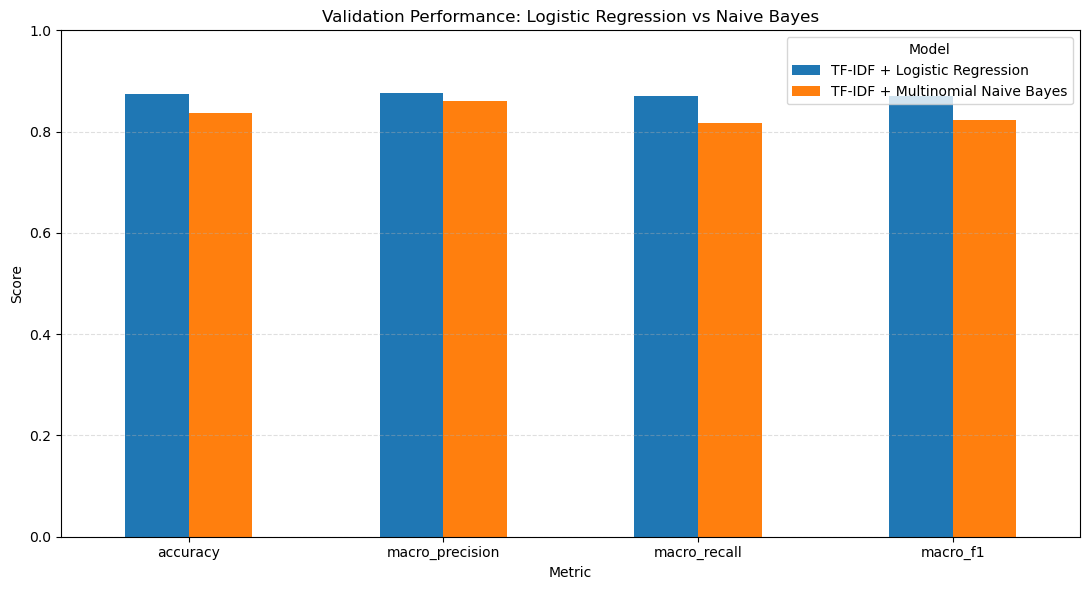

比较图保存路径： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\reports\figures\ml_baseline\logistic_vs_naive_bayes.png


In [70]:
# Cell 80：绘制逻辑回归与朴素贝叶斯性能比较图

comparison_plot_df = (
    model_comparison_df[
        [
            "model",
            "accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
        ]
    ]
    .set_index("model")
    .transpose()
)

figure, axis = plt.subplots(
    figsize=(11, 6)
)

comparison_plot_df.plot(
    kind="bar",
    ax=axis
)

axis.set_title(
    "Validation Performance: "
    "Logistic Regression vs Naive Bayes"
)

axis.set_xlabel("Metric")
axis.set_ylabel("Score")

axis.set_ylim(0, 1)

axis.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

axis.legend(
    title="Model"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

model_comparison_figure_path = (
    FIGURE_DIR
    / "logistic_vs_naive_bayes.png"
)

plt.savefig(
    model_comparison_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "比较图保存路径：",
    model_comparison_figure_path
)

## 比较训练时间

In [71]:
# Cell 81：比较训练时间和推理时间

speed_comparison_df = model_comparison_df[
    [
        "model",
        "training_time_seconds",
        "validation_inference_time_seconds",
    ]
].copy()

display(speed_comparison_df)

,model,training_time_seconds,validation_inference_time_seconds
0,TF-IDF + Logistic Regression,0.914540,0.001977
1,TF-IDF + Multinomial Naive Bayes,0.022907,0.001711


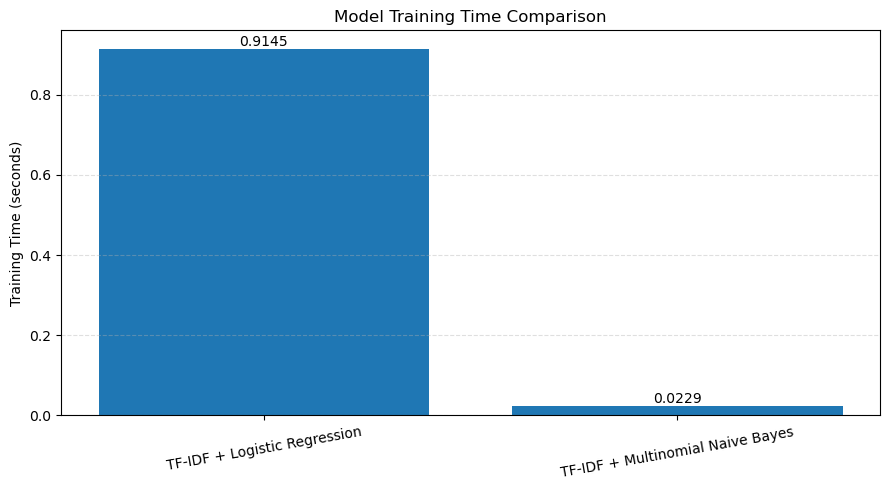

In [72]:
# Cell 82：绘制训练时间比较

figure, axis = plt.subplots(
    figsize=(9, 5)
)

bars = axis.bar(
    model_comparison_df["model"],
    model_comparison_df[
        "training_time_seconds"
    ]
)

axis.set_title(
    "Model Training Time Comparison"
)

axis.set_ylabel(
    "Training Time (seconds)"
)

axis.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    model_comparison_df[
        "training_time_seconds"
    ]
):
    axis.text(
        bar.get_x()
        + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(
    rotation=10
)

plt.tight_layout()

training_time_figure_path = (
    FIGURE_DIR
    / "model_training_time_comparison.png"
)

plt.savefig(
    training_time_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
# Cell 85：保存模型比较结果

MODEL_COMPARISON_PATH = (
    BASELINE_REPORT_DIR
    / "traditional_model_comparison.csv"
)

NB_CLASSIFICATION_REPORT_PATH = (
    BASELINE_REPORT_DIR
    / "naive_bayes_classification_report.csv"
)

NB_CONFUSION_PATH = (
    BASELINE_REPORT_DIR
    / "naive_bayes_top_confusions.csv"
)

model_comparison_df.to_csv(
    MODEL_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)

nb_report_df.to_csv(
    NB_CLASSIFICATION_REPORT_PATH,
    encoding="utf-8-sig"
)

nb_top_confusion_pairs_df.to_csv(
    NB_CONFUSION_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "模型比较结果：",
    MODEL_COMPARISON_PATH
)

print(
    "朴素贝叶斯分类报告：",
    NB_CLASSIFICATION_REPORT_PATH
)

print(
    "朴素贝叶斯混淆结果：",
    NB_CONFUSION_PATH
)

模型比较结果： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\reports\ml_baseline\traditional_model_comparison.csv
朴素贝叶斯分类报告： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\reports\ml_baseline\naive_bayes_classification_report.csv
朴素贝叶斯混淆结果： c:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\reports\ml_baseline\naive_bayes_top_confusions.csv


In [74]:
# Cell 86：当前实验状态

print("当前传统机器学习阶段：")
print("1. TF-IDF特征提取：完成")
print("2. 逻辑回归Baseline：完成")
print("3. Multinomial Naive Bayes：完成")
print("4. 两个模型验证集比较：完成")
print("5. 训练和推理成本比较：完成")
print("6. 当前仍未使用测试集")
print("7. 下一模型：Linear SVM")

当前传统机器学习阶段：
1. TF-IDF特征提取：完成
2. 逻辑回归Baseline：完成
3. Multinomial Naive Bayes：完成
4. 两个模型验证集比较：完成
5. 训练和推理成本比较：完成
6. 当前仍未使用测试集
7. 下一模型：Linear SVM


## SVM

In [75]:
# Cell 87：导入Linear SVM

from sklearn.svm import LinearSVC

print("LinearSVC导入完成。")

LinearSVC导入完成。


In [76]:
# Cell 88：检查前面的TF-IDF数据是否存在

required_variables = [
    "X_train_tfidf",
    "X_validation_tfidf",
    "y_train",
    "y_validation",
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise NameError(
            f"缺少变量：{variable_name}，"
            "请先完成TF-IDF特征提取。"
        )

print("训练集TF-IDF形状：", X_train_tfidf.shape)
print("验证集TF-IDF形状：", X_validation_tfidf.shape)

print("TF-IDF数据检查通过。")

训练集TF-IDF形状： (9149, 1416)
验证集TF-IDF形状： (1961, 1416)
TF-IDF数据检查通过。


In [77]:
# Cell 89：创建Linear SVM模型

linear_svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

print(linear_svm_model)

LinearSVC(max_iter=5000, random_state=42)


In [78]:
# Cell 90：训练Linear SVM

import time

svm_training_start_time = time.perf_counter()

linear_svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_training_time = (
    time.perf_counter()
    - svm_training_start_time
)

print("Linear SVM训练完成。")
print(f"训练耗时：{svm_training_time:.6f}秒")
print("模型类别数量：", len(linear_svm_model.classes_))

Linear SVM训练完成。
训练耗时：0.345263秒
模型类别数量： 77


In [79]:
# Cell 91：在验证集上预测

svm_prediction_start_time = time.perf_counter()

svm_validation_predictions = linear_svm_model.predict(
    X_validation_tfidf
)

svm_prediction_time = (
    time.perf_counter()
    - svm_prediction_start_time
)

print("验证集预测完成。")
print("预测样本数量：", len(svm_validation_predictions))

print(
    f"验证集总推理耗时："
    f"{svm_prediction_time:.6f}秒"
)

print(
    "平均每条工单推理耗时：",
    f"{svm_prediction_time / len(y_validation):.8f}秒"
)

验证集预测完成。
预测样本数量： 1961
验证集总推理耗时：0.001543秒
平均每条工单推理耗时： 0.00000079秒


In [80]:
# Cell 92：计算Linear SVM验证集指标

svm_validation_accuracy = accuracy_score(
    y_validation,
    svm_validation_predictions
)

svm_validation_macro_precision = precision_score(
    y_validation,
    svm_validation_predictions,
    average="macro",
    zero_division=0
)

svm_validation_macro_recall = recall_score(
    y_validation,
    svm_validation_predictions,
    average="macro",
    zero_division=0
)

svm_validation_macro_f1 = f1_score(
    y_validation,
    svm_validation_predictions,
    average="macro",
    zero_division=0
)

svm_metrics_df = pd.DataFrame(
    {
        "model": [
            "TF-IDF + Linear SVM"
        ],
        "accuracy": [
            svm_validation_accuracy
        ],
        "macro_precision": [
            svm_validation_macro_precision
        ],
        "macro_recall": [
            svm_validation_macro_recall
        ],
        "macro_f1": [
            svm_validation_macro_f1
        ],
        "training_time_seconds": [
            svm_training_time
        ],
        "validation_inference_time_seconds": [
            svm_prediction_time
        ],
    }
)

display(svm_metrics_df)

,model,accuracy,macro_precision,macro_recall,macro_f1,training_time_seconds,validation_inference_time_seconds
0,TF-IDF + Linear SVM,0.890362,0.890312,0.888143,0.88761,0.345263,0.001543


In [81]:
# Cell 93：生成Linear SVM详细分类报告

svm_classification_report = classification_report(
    y_validation,
    svm_validation_predictions,
    labels=linear_svm_model.classes_,
    output_dict=True,
    zero_division=0,
)

svm_report_df = (
    pd.DataFrame(svm_classification_report)
    .transpose()
)

display(svm_report_df)

,precision,recall,f1-score,support
Refund_not_showing_up,0.966667,0.935484,0.950820,31.000000
activate_my_card,0.965517,0.933333,0.949153,30.000000
age_limit,1.000000,1.000000,1.000000,23.000000
apple_pay_or_google_pay,1.000000,0.920000,0.958333,25.000000
atm_support,0.894737,0.944444,0.918919,18.000000
...,...,...,...,...
wrong_amount_of_cash_received,0.903226,0.848485,0.875000,33.000000
wrong_exchange_rate_for_cash_withdrawal,0.961538,0.833333,0.892857,30.000000
accuracy,0.890362,0.890362,0.890362,0.890362
macro avg,0.890312,0.888143,0.887610,1961.000000


In [82]:
# Cell 94：查看Recall最低的10个类别

svm_per_class_report_df = svm_report_df.loc[
    linear_svm_model.classes_
].copy()

svm_lowest_recall_classes = (
    svm_per_class_report_df
    .sort_values(
        by="recall",
        ascending=True
    )
    .head(10)
)

print("Linear SVM Recall最低的10个类别：")

display(
    svm_lowest_recall_classes[
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ]
)

Linear SVM Recall最低的10个类别：


,precision,recall,f1-score,support
virtual_card_not_working,0.700000,0.583333,0.636364,12.0
declined_transfer,0.818182,0.692308,0.750000,26.0
card_not_working,0.842105,0.727273,0.780488,22.0
lost_or_stolen_card,0.777778,0.736842,0.756757,19.0
card_delivery_estimate,0.739130,0.739130,0.739130,23.0
transfer_fee_charged,0.888889,0.750000,0.813559,32.0
transfer_timing,0.826087,0.760000,0.791667,25.0
declined_cash_withdrawal,0.862069,0.781250,0.819672,32.0
compromised_card,0.750000,0.789474,0.769231,19.0
order_physical_card,0.791667,0.791667,0.791667,24.0


In [83]:
# Cell 95：计算Linear SVM混淆矩阵

svm_class_labels = linear_svm_model.classes_

svm_confusion_matrix = confusion_matrix(
    y_validation,
    svm_validation_predictions,
    labels=svm_class_labels
)

print(
    "Linear SVM混淆矩阵形状：",
    svm_confusion_matrix.shape
)

assert svm_confusion_matrix.shape == (77, 77)

print("77分类混淆矩阵计算完成。")

Linear SVM混淆矩阵形状： (77, 77)
77分类混淆矩阵计算完成。


In [84]:
# Cell 96：找出Linear SVM最常见的错误类别组合

svm_confusion_records = []

for true_index, true_label in enumerate(
    svm_class_labels
):
    for predicted_index, predicted_label in enumerate(
        svm_class_labels
    ):

        if true_index == predicted_index:
            continue

        confusion_count = svm_confusion_matrix[
            true_index,
            predicted_index
        ]

        if confusion_count > 0:
            svm_confusion_records.append(
                {
                    "true_category": true_label,
                    "predicted_category": predicted_label,
                    "confusion_count": int(
                        confusion_count
                    ),
                }
            )

svm_confusion_pairs_df = pd.DataFrame(
    svm_confusion_records
)

svm_top_confusion_pairs_df = (
    svm_confusion_pairs_df
    .sort_values(
        by="confusion_count",
        ascending=False
    )
    .head(20)
)

print("Linear SVM最常见的20组错误混淆：")

display(svm_top_confusion_pairs_df)

Linear SVM最常见的20组错误混淆：


,true_category,predicted_category,confusion_count
156,virtual_card_not_working,get_disposable_virtual_card,4
138,transfer_fee_charged,top_up_by_bank_transfer_charge,4
162,wrong_amount_of_cash_received,declined_cash_withdrawal,3
151,unable_to_verify_identity,why_verify_identity,3
149,transfer_timing,transfer_not_received_by_recipient,3
148,transfer_timing,pending_transfer,3
57,declined_transfer,declined_card_payment,3
58,declined_transfer,failed_transfer,3
0,Refund_not_showing_up,request_refund,2
66,disposable_card_limits,get_disposable_virtual_card,2


## 三模型对比

In [85]:
# Cell 97：比较三个传统机器学习模型

three_model_comparison_df = pd.concat(
    [
        baseline_metrics_df,
        nb_metrics_df,
        svm_metrics_df
    ],
    ignore_index=True
)

display(three_model_comparison_df)

,model,accuracy,macro_precision,macro_recall,macro_f1,training_time_seconds,validation_inference_time_seconds
0,TF-IDF + Logistic Regression,0.873534,0.877014,0.870031,0.870212,0.914540,0.001977
1,TF-IDF + Multinomial Naive Bayes,0.836818,0.859977,0.817761,0.822571,0.022907,0.001711
2,TF-IDF + Linear SVM,0.890362,0.890312,0.888143,0.887610,0.345263,0.001543


In [86]:
# Cell 98：按照Macro-F1排序

three_model_ranking_df = (
    three_model_comparison_df
    .sort_values(
        by="macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(three_model_ranking_df)

,model,accuracy,macro_precision,macro_recall,macro_f1,training_time_seconds,validation_inference_time_seconds
0,TF-IDF + Linear SVM,0.890362,0.890312,0.888143,0.887610,0.345263,0.001543
1,TF-IDF + Logistic Regression,0.873534,0.877014,0.870031,0.870212,0.914540,0.001977
2,TF-IDF + Multinomial Naive Bayes,0.836818,0.859977,0.817761,0.822571,0.022907,0.001711


In [87]:
# Cell 99：计算Linear SVM相对逻辑回归的变化

logistic_accuracy = (
    baseline_metrics_df.iloc[0]["accuracy"]
)

logistic_macro_f1 = (
    baseline_metrics_df.iloc[0]["macro_f1"]
)

svm_accuracy_difference = (
    svm_validation_accuracy
    - logistic_accuracy
)

svm_macro_f1_difference = (
    svm_validation_macro_f1
    - logistic_macro_f1
)

print(
    "Linear SVM相对逻辑回归 Accuracy变化：",
    f"{svm_accuracy_difference:+.4f}"
)

print(
    "Linear SVM相对逻辑回归 Macro-F1变化：",
    f"{svm_macro_f1_difference:+.4f}"
)

Linear SVM相对逻辑回归 Accuracy变化： +0.0168
Linear SVM相对逻辑回归 Macro-F1变化： +0.0174


In [88]:
# Cell 100：查看Linear SVM决策分数

svm_decision_scores = linear_svm_model.decision_function(
    X_validation_tfidf
)

print(
    "决策分数矩阵形状：",
    svm_decision_scores.shape
)

print(
    "第一条验证样本的前10个类别决策分数："
)

print(
    svm_decision_scores[0][:10]
)

决策分数矩阵形状： (1961, 77)
第一条验证样本的前10个类别决策分数：
[-1.52787494 -1.41363919 -1.08283944 -1.10210026 -1.64127395 -1.17036282
 -1.69741923 -1.3680257  -1.52630609 -1.6803629 ]


In [89]:
# Cell 101：获取每条工单最高决策分数

svm_max_decision_scores = (
    svm_decision_scores.max(axis=1)
)

print(
    "平均最高决策分数：",
    svm_max_decision_scores.mean()
)

print(
    "最低最高决策分数：",
    svm_max_decision_scores.min()
)

print(
    "最高决策分数：",
    svm_max_decision_scores.max()
)

平均最高决策分数： 0.49365403334623353
最低最高决策分数： -1.0133058947233833
最高决策分数： 2.71420770600683


In [90]:
# Cell 102：保存Linear SVM实验结果

SVM_METRICS_PATH = (
    BASELINE_REPORT_DIR
    / "linear_svm_validation_metrics.csv"
)

SVM_CLASSIFICATION_REPORT_PATH = (
    BASELINE_REPORT_DIR
    / "linear_svm_classification_report.csv"
)

SVM_CONFUSION_PATH = (
    BASELINE_REPORT_DIR
    / "linear_svm_top_confusions.csv"
)

THREE_MODEL_COMPARISON_PATH = (
    BASELINE_REPORT_DIR
    / "three_model_comparison.csv"
)

svm_metrics_df.to_csv(
    SVM_METRICS_PATH,
    index=False,
    encoding="utf-8-sig"
)

svm_report_df.to_csv(
    SVM_CLASSIFICATION_REPORT_PATH,
    encoding="utf-8-sig"
)

svm_top_confusion_pairs_df.to_csv(
    SVM_CONFUSION_PATH,
    index=False,
    encoding="utf-8-sig"
)

three_model_comparison_df.to_csv(
    THREE_MODEL_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Linear SVM实验结果保存完成。")

Linear SVM实验结果保存完成。
